In [13]:
%pip install scikit-learn

In [14]:
import sklearn
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.7.0


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [24]:
df = pd.read_csv('winequality-white.csv')
df           

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [25]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [27]:
total_nulls = df.isnull().sum().sum()
total_nulls

np.int64(0)

In [28]:
has_any_nulls = df.isnull().any().any()   # return True if any nulls exist , False otherwise
has_any_nulls

np.False_

In [29]:
df.shape

(4898, 12)

In [31]:
df.columns


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [32]:
df.columns =(
    df.columns
    .str.replace(" ", "_")
)
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [33]:
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(937)

In [35]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

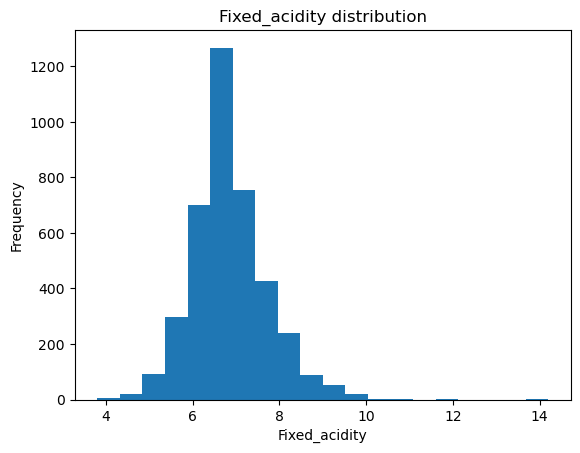

In [39]:
# histogram of fixed acidity
plt.figure()
plt.hist(df['fixed_acidity'], bins=20)
plt.title("Fixed_acidity distribution")
plt.xlabel("Fixed_acidity")
plt.ylabel("Frequency")
plt.show()


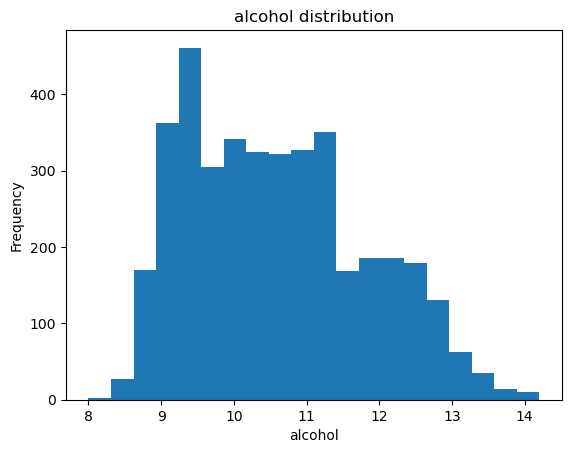

In [51]:
# hist alchol
plt.figure()
plt.hist(df['alcohol'], bins=20)
plt.title("alcohol distribution")
plt.xlabel("alcohol")
plt.ylabel("Frequency")
plt.show()

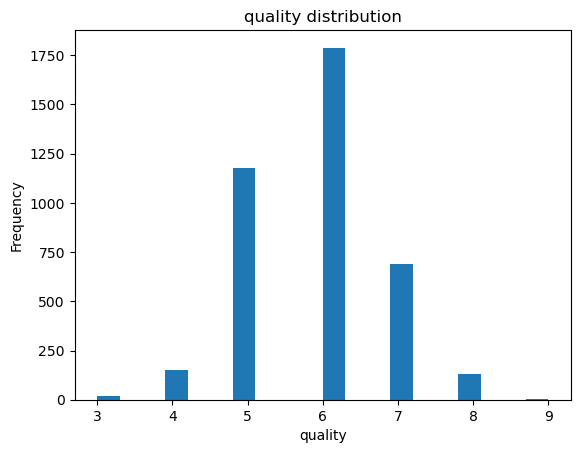

In [52]:
# hist quality
plt.figure()
plt.hist(df['quality'], bins=20)
plt.title("quality distribution")
plt.xlabel("quality")
plt.ylabel("Frequency")
plt.show()

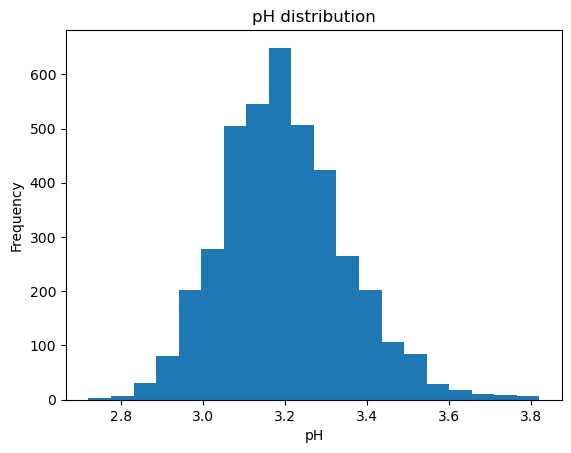

In [40]:
# histogram of pH
plt.figure()
plt.hist(df['pH'], bins=20)
plt.title("pH distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

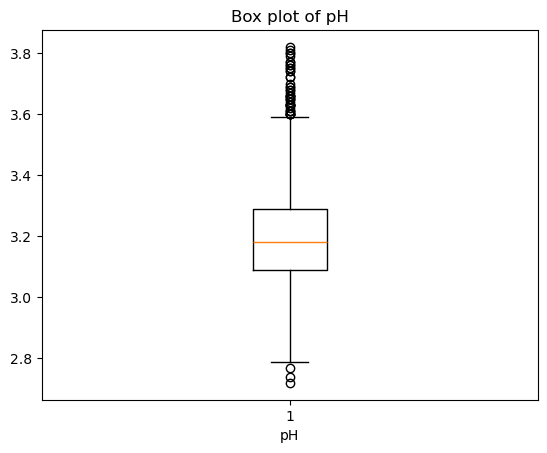

In [53]:
# box plot of citric_acid
plt.figure()
plt.boxplot(df['pH'])
plt.title("Box plot of pH")
plt.xlabel("pH")
plt.show()

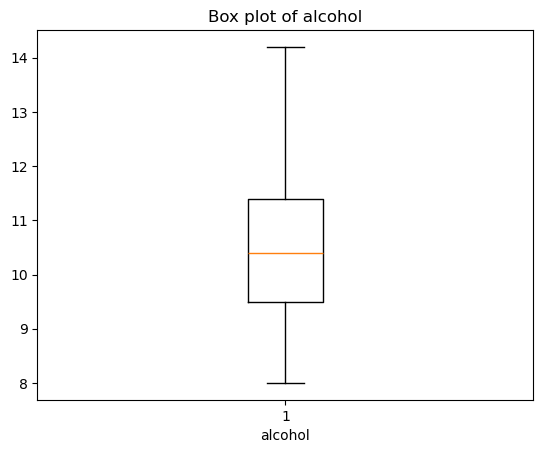

In [56]:
# box plot of citric_acid
plt.figure()
plt.boxplot(df['alcohol'])
plt.title("Box plot of alcohol")
plt.xlabel("alcohol")
plt.show()
           

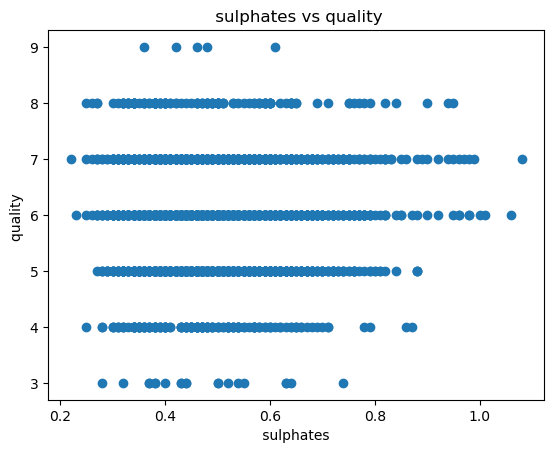

In [57]:
# scatter plot of sulphates vs quality
plt.figure()
plt.scatter(df['sulphates'], df['quality'])
plt.title(" sulphates vs quality")
plt.xlabel(" sulphates ")
plt.ylabel("quality ")
plt.show()
    

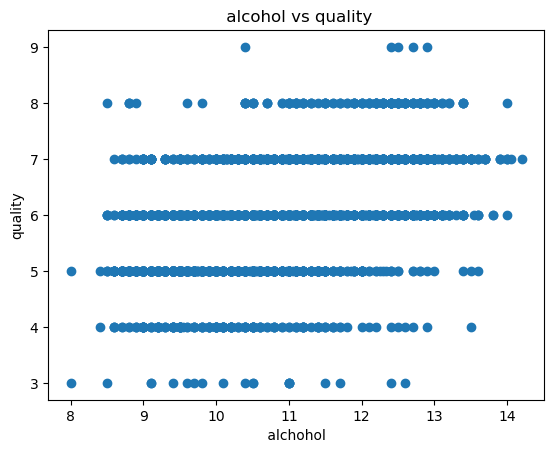

In [55]:
# scatter plot of alcohol vs quality
plt.figure()
plt.scatter(df['alcohol'], df['quality'])
plt.title(" alcohol vs quality")
plt.xlabel(" alchohol ")
plt.ylabel("quality")
plt.show()
    

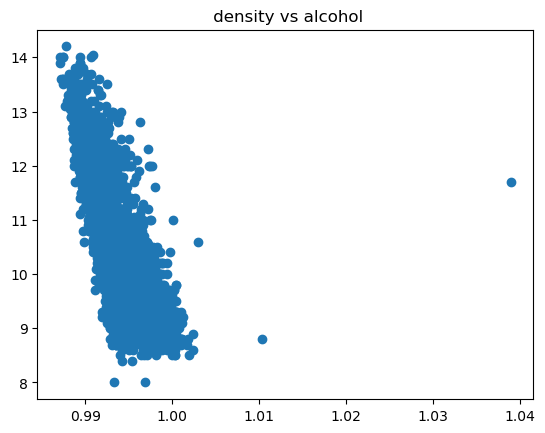

In [61]:
# scatter plot of density vs alcohol
plt.figure()
plt.scatter(df['density'], df['alcohol'])
plt.title(" density vs alcohol")
plt.show()

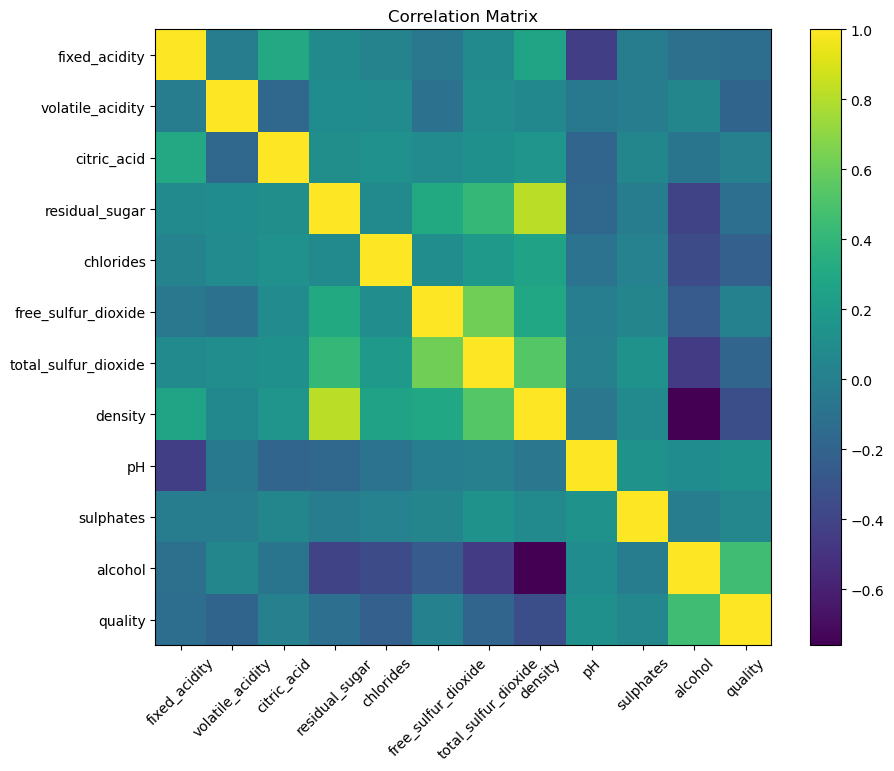

In [58]:
#  Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

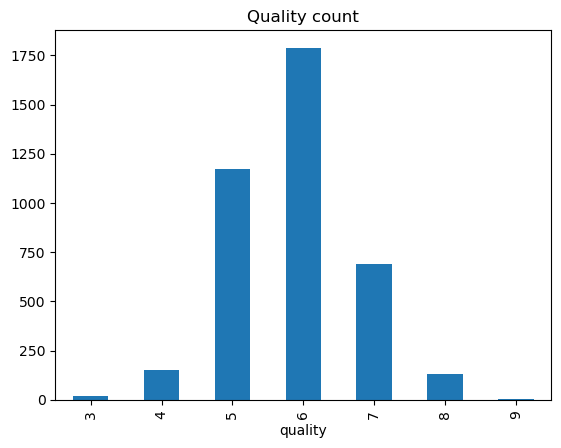

In [59]:
# bar - quality count
plt.figure()
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Quality count")
plt.show()

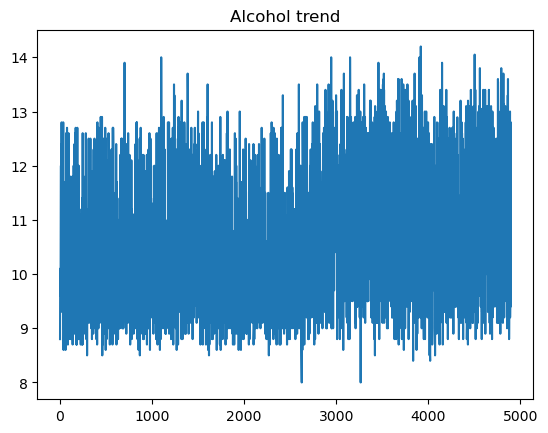

In [60]:
# line - alcohol
plt.figure()
plt.plot(df['alcohol'])
plt.title("Alcohol trend")
plt.show()

In [48]:
df.corr(numeric_only = True)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.019214,0.298959,0.083620,0.024036,-0.058396,0.082425,0.266091,-0.431274,-0.017453,-0.110788,-0.124636
volatile_acidity,-0.019214,1.000000,-0.163228,0.098340,0.086287,-0.102471,0.102315,0.060603,-0.046954,-0.021150,0.046815,-0.190678
citric_acid,0.298959,-0.163228,1.000000,0.106269,0.132590,0.091681,0.122845,0.160076,-0.183015,0.049442,-0.076514,0.007065
residual_sugar,0.083620,0.098340,0.106269,1.000000,0.076091,0.306835,0.409583,0.820498,-0.165997,-0.020503,-0.398167,-0.117339
chlorides,0.024036,0.086287,0.132590,0.076091,1.000000,0.101272,0.191145,0.253088,-0.090573,0.017871,-0.356928,-0.217739
free_sulfur_dioxide,-0.058396,-0.102471,0.091681,0.306835,0.101272,1.000000,0.619437,0.294638,-0.007750,0.037932,-0.251768,0.010507
total_sulfur_dioxide,0.082425,0.102315,0.122845,0.409583,0.191145,0.619437,1.000000,0.536868,0.008239,0.136544,-0.446643,-0.183356
density,0.266091,0.060603,0.160076,0.820498,0.253088,0.294638,0.536868,1.000000,-0.063734,0.082048,-0.760162,-0.337805
pH,-0.431274,-0.046954,-0.183015,-0.165997,-0.090573,-0.007750,0.008239,-0.063734,1.000000,0.142353,0.093095,0.123829
sulphates,-0.017453,-0.021150,0.049442,-0.020503,0.017871,0.037932,0.136544,0.082048,0.142353,1.000000,-0.022850,0.053200


In [50]:
# absolute
abs(df.corr(numeric_only=True))['fixed_acidity'].sort_values(ascending=False)

fixed_acidity           1.000000
pH                      0.431274
citric_acid             0.298959
density                 0.266091
quality                 0.124636
alcohol                 0.110788
residual_sugar          0.083620
total_sulfur_dioxide    0.082425
free_sulfur_dioxide     0.058396
chlorides               0.024036
volatile_acidity        0.019214
sulphates               0.017453
Name: fixed_acidity, dtype: float64